## Physics-informed input convex neural network (PINN)

### Train PINN

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import os
import shutil
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='tensorflow')


# === Reproducibility Setup ===
np.random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

# === Define Trainable Physics Parameters ===
class PhysicsParams(tf.keras.layers.Layer):
    def __init__(self):
        '''
        Physical Equation:
        residual = (dTz / dt) - α * (Tout - Tz) - β1 * occupancy - β2 * solar + β3 * systemPower
        Minimize residual during PINN training
        '''
        super().__init__()
        self.alpha = tf.Variable(0.5, trainable=True, dtype=tf.float32)
        self.beta1 = tf.Variable(1.0, trainable=True, dtype=tf.float32)
        self.beta2 = tf.Variable(0.01, trainable=True, dtype=tf.float32)
        self.beta3 = tf.Variable(0.0001, trainable=True, dtype=tf.float32)

    def get_params(self):
        return self.alpha, self.beta1, self.beta2, self.beta3

# === Custom Loss Function ===
def compute_loss(model, physics_params, x, y, idx):
    with tf.GradientTape() as tape:
        tape.watch(x)
        y_pred = model(x)
    dT_dt = tape.gradient(y_pred, x)[:, idx['time']]

    T_z = y_pred[:, 0]
    T_out = x[:, idx['T_out']]
    occ = x[:, idx['occ']]
    solar = x[:, idx['solar']]
    system_power = x[:, idx['power']]
    uMod = x[:, idx['uMod']]
    cooling_active = tf.cast(tf.logical_or(tf.equal(uMod, 1), tf.equal(uMod, 2)), tf.float32)
    effective_power = system_power * cooling_active

    alpha, beta1, beta2, beta3 = physics_params.get_params()
    residual = dT_dt - alpha * (T_out - T_z) - beta1 * occ - beta2 * solar + beta3 * effective_power
    residual_loss = tf.reduce_mean(tf.square(residual))
    mse_loss = tf.reduce_mean(tf.square(y - y_pred))
    bound_loss = tf.reduce_mean(tf.square(tf.maximum(0.0, T_z - 32)) + tf.square(tf.maximum(0.0, 20 - T_z)))

    return mse_loss + 0.1 * residual_loss + 0.01 * bound_loss, mse_loss.numpy(), residual_loss.numpy(), bound_loss.numpy()

# === Define Model ===
def build_model(input_dim):
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(1)
    ])

# === Train PINN with EarlyStopping and K-Fold, Save Only Best Fold ===
def train_pinn(data, features, target, feature_indices, zone_name, coeffs, lr=1e-3, epochs=2000, n_splits=5):
    x = data[features].values.astype(np.float32)
    y = data[target].values.astype(np.float32)

    kf = KFold(n_splits=n_splits, shuffle=False)
    fold = 1
    best_fold_loss = float('inf')
    best_fold_model_path = ''

    for train_idx, val_idx in kf.split(x):
        print(f"\n--- Fold {fold}/{n_splits} ---")
        x_train, x_val = x[train_idx], x[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model = build_model(x.shape[1])
        physics_params = PhysicsParams(*coeffs)
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
        best_loss = float('inf')
        patience = 20
        wait = 0

        history = []
        for epoch in range(epochs):
            x_tensor = tf.convert_to_tensor(x_train, dtype=tf.float32)
            y_tensor = tf.convert_to_tensor(y_train, dtype=tf.float32)

            with tf.GradientTape() as tape:
                loss, mse, res, bnd = compute_loss(model, physics_params, x_tensor, y_tensor, feature_indices)
            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

            history.append([loss.numpy(), mse, res, bnd])

            if loss < best_loss:
                best_loss = loss
                wait = 0
                model_path = f'./results_pinn/pinn_model_{zone_name}_fold{fold}.h5'
                model.save(model_path)
            else:
                wait += 1
                if wait >= patience:
                    print(f"Early stopping at epoch {epoch}")
                    break

            if epoch % 100 == 0:
                print(f"Epoch {epoch}: Loss={loss:.4f} MSE={mse:.4f} Residual={res:.4f} Bound={bnd:.4f}")

        if best_loss < best_fold_loss:
            best_fold_loss = best_loss
            best_fold_model_path = model_path

        fold += 1

    for k in range(1, n_splits + 1):
        path = f'./results_pinn/pinn_model_{zone_name}_fold{k}.h5'
        if path != best_fold_model_path and os.path.exists(path):
            os.remove(path)
    shutil.move(best_fold_model_path, f'./results_pinn/pinn_model_{zone_name}.h5')
    print(f'✅ Best fold model saved as: ./results_pinn/pinn_model_{zone_name}.h5')

# === Load Data ===
df = pd.read_csv('prepared_data_1hr.csv', index_col=0)

# === Coefficient Curve Fitting ===
def estimate_physics_coefficients(df, features, target, index_map):
    Tz = df[target].values
    Tout = df[features[index_map['T_out']]].values
    occ = df[features[index_map['occ']]].values
    solar = df[features[index_map['solar']]].values
    power = df[features[index_map['power']]].values
    uMod = df[features[index_map['uMod']]].values

    # compute dTz/dt (forward difference)
    dTz_dt = np.gradient(Tz)

    # define cooling active mask
    cooling_active = ((uMod == 1) | (uMod == 2)).astype(float)
    eff_power = power * cooling_active

    X_fit = np.column_stack([
        Tout - Tz,
        occ,
        solar,
        -eff_power
    ])
    y_fit = dTz_dt

    reg = LinearRegression().fit(X_fit, y_fit)
    alpha, beta1, beta2, beta3 = reg.coef_
    print(f"🔧 Curve-fitted coefficients: alpha={alpha:.4f}, beta1={beta1:.4f}, beta2={beta2:.4f}, beta3={beta3:.4f}")
    return alpha, beta1, beta2, beta3

# Feature Mappings
template_features = ['TZon_his1', 'uMod', 'T_out', 'occupied', 'solar', 'system_power']
zone_configs = {
    'core': ([f'tesBed.conVAVCor.{template_features[0]}', 'tesBed.uModActual.y', 'tesBed.TOut.y',
              'tesBed.occSch.occupied', 'tesBed.weaBus.HGloHor', 'Ptot'], 'tesBed.conVAVCor.TZon'),
    # Add more zones here if needed
}

def get_index_map(features):
    return {
        'T_out': features.index('tesBed.TOut.y'),
        'occ': features.index('tesBed.occSch.occupied'),
        'solar': features.index('tesBed.weaBus.HGloHor'),
        'power': features.index('Ptot'),
        'uMod': features.index('tesBed.uModActual.y'),
        'time': 0
    }

for zone, (feat, tgt) in zone_configs.items():
    print(f"\n=== Training PINN for {zone.upper()} zone ===")
    index_map = get_index_map(feat)
    coeffs = estimate_physics_coefficients(df, feat, tgt, index_map)
    train_pinn(df, feat, tgt, index_map, zone, coeffs)



=== Training PINN for CORE zone ===
🔧 Curve-fitted coefficients: alpha=0.0105, beta1=-0.0522, beta2=0.0003, beta3=0.0000

--- Fold 1/5 ---


TypeError: __init__() takes 1 positional argument but 5 were given

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import os
import shutil
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='tensorflow')

# === Reproducibility Setup ===
np.random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

# === Flexible Physics Parameters (trainable or fixed) ===
class PhysicsParams:
    def __init__(self, alpha, beta1, beta2, beta3, trainable=False):
        '''
        Physical Equation:
        residual = (dTz / dt) - α * (Tout - Tz) - β1 * occupancy - β2 * solar + β3 * systemPower
        Minimize residual during PINN training
        '''
        dtype = tf.float32
        if trainable:
            self.alpha = tf.Variable(alpha, trainable=True, dtype=dtype)
            self.beta1 = tf.Variable(beta1, trainable=True, dtype=dtype)
            self.beta2 = tf.Variable(beta2, trainable=True, dtype=dtype)
            self.beta3 = tf.Variable(beta3, trainable=True, dtype=dtype)
        else:
            self.alpha = tf.constant(alpha, dtype=dtype)
            self.beta1 = tf.constant(beta1, dtype=dtype)
            self.beta2 = tf.constant(beta2, dtype=dtype)
            self.beta3 = tf.constant(beta3, dtype=dtype)
        self.trainable = trainable

    def get_params(self):
        return self.alpha, self.beta1, self.beta2, self.beta3

    def trainable_variables(self):
        if self.trainable:
            return [self.alpha, self.beta1, self.beta2, self.beta3]
        return []

# === Custom Loss Function ===
def compute_loss(model, physics_params, x, y, idx):
    with tf.GradientTape() as tape:
        tape.watch(x)
        y_pred = model(x)
    dT_dt = tape.gradient(y_pred, x)[:, idx['time']]

    T_z = y_pred[:, 0]
    T_out = x[:, idx['T_out']]
    occ = x[:, idx['occ']]
    solar = x[:, idx['solar']]
    system_power = x[:, idx['power']]
    uMod = x[:, idx['uMod']]
    cooling_active = tf.cast(tf.logical_or(tf.equal(uMod, 1), tf.equal(uMod, 2)), tf.float32)
    effective_power = system_power * cooling_active

    alpha, beta1, beta2, beta3 = physics_params.get_params()
    residual = dT_dt - alpha * (T_out - T_z) - beta1 * occ - beta2 * solar + beta3 * effective_power
    residual_loss = tf.reduce_mean(tf.square(residual))
    mse_loss = tf.reduce_mean(tf.square(y - y_pred))
    bound_loss = tf.reduce_mean(tf.square(tf.maximum(0.0, T_z - 32)) + tf.square(tf.maximum(0.0, 20 - T_z)))

    return mse_loss + 0.01 * residual_loss + 0.01 * bound_loss, mse_loss.numpy(), residual_loss.numpy(), bound_loss.numpy()

# === Define Model ===
def build_model(input_dim):
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(1)
    ])

# === Train PINN with EarlyStopping and K-Fold, Save Only Best Fold ===
def train_pinn(data, features, target, feature_indices, zone_name, coeffs, trainable_coeffs=False, lr=1e-3, epochs=2000, n_splits=5):
    x = data[features].values.astype(np.float32)
    y = data[target].values.astype(np.float32)

    kf = KFold(n_splits=n_splits, shuffle=False)
    fold = 1
    best_fold_loss = float('inf')
    best_fold_model_path = ''

    for train_idx, val_idx in kf.split(x):
        print(f"\n--- Fold {fold}/{n_splits} ---")
        x_train, x_val = x[train_idx], x[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model = build_model(x.shape[1])
        physics_params = PhysicsParams(*coeffs, trainable=trainable_coeffs)
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
        best_loss = float('inf')
        patience = 20
        wait = 0

        history = []
        for epoch in range(epochs):
            x_tensor = tf.convert_to_tensor(x_train, dtype=tf.float32)
            y_tensor = tf.convert_to_tensor(y_train, dtype=tf.float32)

            with tf.GradientTape() as tape:
                loss, mse, res, bnd = compute_loss(model, physics_params, x_tensor, y_tensor, feature_indices)
            grads = tape.gradient(loss, model.trainable_variables + physics_params.trainable_variables())
            optimizer.apply_gradients(zip(grads, model.trainable_variables + physics_params.trainable_variables()))

            history.append([loss.numpy(), mse, res, bnd])

            if loss < best_loss:
                best_loss = loss
                wait = 0
                model_path = f'./results_pinn/pinn_model_{zone_name}_fold{fold}.h5'
                model.save(model_path)
            else:
                wait += 1
                if wait >= patience:
                    print(f"Early stopping at epoch {epoch}")
                    break

            if epoch % 100 == 0:
                print(f"Epoch {epoch}: Loss={loss:.4f} MSE={mse:.4f} Residual={res:.4f} Bound={bnd:.4f}")

        if best_loss < best_fold_loss:
            best_fold_loss = best_loss
            best_fold_model_path = model_path

        fold += 1

    for k in range(1, n_splits + 1):
        path = f'./results_pinn/pinn_model_{zone_name}_fold{k}.h5'
        if path != best_fold_model_path and os.path.exists(path):
            os.remove(path)
    shutil.move(best_fold_model_path, f'./results_pinn/pinn_model_{zone_name}.h5')
    print(f'✅ Best fold model saved as: ./results_pinn/pinn_model_{zone_name}.h5')

# === Load Data ===
df = pd.read_csv('prepared_data_1hr.csv', index_col=0)

# === Coefficient Curve Fitting ===
def estimate_physics_coefficients(df, features, target, index_map):
    Tz = df[target].values
    Tout = df[features[index_map['T_out']]].values
    occ = df[features[index_map['occ']]].values
    solar = df[features[index_map['solar']]].values
    power = df[features[index_map['power']]].values
    uMod = df[features[index_map['uMod']]].values

    dTz_dt = np.gradient(Tz)
    cooling_active = ((uMod == 1) | (uMod == 2)).astype(float)
    eff_power = power * cooling_active

    X_fit = np.column_stack([
        Tout - Tz,
        occ,
        solar,
        -eff_power
    ])
    y_fit = dTz_dt

    reg = LinearRegression().fit(X_fit, y_fit)
    alpha, beta1, beta2, beta3 = reg.coef_
    print(f"🔧 Curve-fitted coefficients: alpha={alpha:.4f}, beta1={beta1:.4f}, beta2={beta2:.4f}, beta3={beta3:.4f}")
    return alpha, beta1, beta2, beta3

# Feature Mappings
template_features = ['TZon_his1', 'uMod', 'T_out', 'occupied', 'solar', 'system_power']
zone_configs = {
    'core': ([f'tesBed.conVAVCor.{template_features[0]}', 'tesBed.uModActual.y', 'tesBed.TOut.y',
              'tesBed.occSch.occupied', 'tesBed.weaBus.HGloHor', 'Ptot'], 'tesBed.conVAVCor.TZon'),
    # Add more zones here if needed
}

def get_index_map(features):
    return {
        'T_out': features.index('tesBed.TOut.y'),
        'occ': features.index('tesBed.occSch.occupied'),
        'solar': features.index('tesBed.weaBus.HGloHor'),
        'power': features.index('Ptot'),
        'uMod': features.index('tesBed.uModActual.y'),
        'time': 0
    }

for zone, (feat, tgt) in zone_configs.items():
    print(f"\n=== Training PINN for {zone.upper()} zone ===")
    index_map = get_index_map(feat)
    coeffs = estimate_physics_coefficients(df, feat, tgt, index_map)
    train_pinn(df, feat, tgt, index_map, zone, coeffs, trainable_coeffs=False)



=== Training PINN for CORE zone ===
🔧 Curve-fitted coefficients: alpha=0.0105, beta1=-0.0522, beta2=0.0003, beta3=0.0000

--- Fold 1/5 ---
Epoch 0: Loss=1048396.8750 MSE=1038112.4375 Residual=117.6627 Bound=1028324.1250
Early stopping at epoch 37

--- Fold 2/5 ---
Epoch 0: Loss=417243.0312 MSE=413170.2188 Residual=46.1165 Bound=407235.7188
Epoch 100: Loss=143.4662 MSE=142.8712 Residual=0.1665 Bound=59.3392
Epoch 200: Loss=125.0632 MSE=124.5534 Residual=0.2039 Bound=50.7775
Epoch 300: Loss=115.9185 MSE=115.4633 Residual=0.2222 Bound=45.2967
Epoch 400: Loss=104.9865 MSE=104.5950 Residual=0.2247 Bound=38.9291
Epoch 500: Loss=94.8590 MSE=94.5246 Residual=0.2265 Bound=33.2140
Epoch 600: Loss=84.9123 MSE=84.6324 Residual=0.2292 Bound=27.7625
Epoch 700: Loss=75.1278 MSE=74.8992 Residual=0.2326 Bound=22.6323
Epoch 800: Loss=65.7907 MSE=65.6083 Residual=0.2389 Bound=18.0039
Epoch 900: Loss=56.9706 MSE=56.8296 Residual=0.2447 Bound=13.8623
Epoch 1000: Loss=48.8411 MSE=48.7341 Residual=0.2551 Bo

#### Curve-fitting for the physical loss function

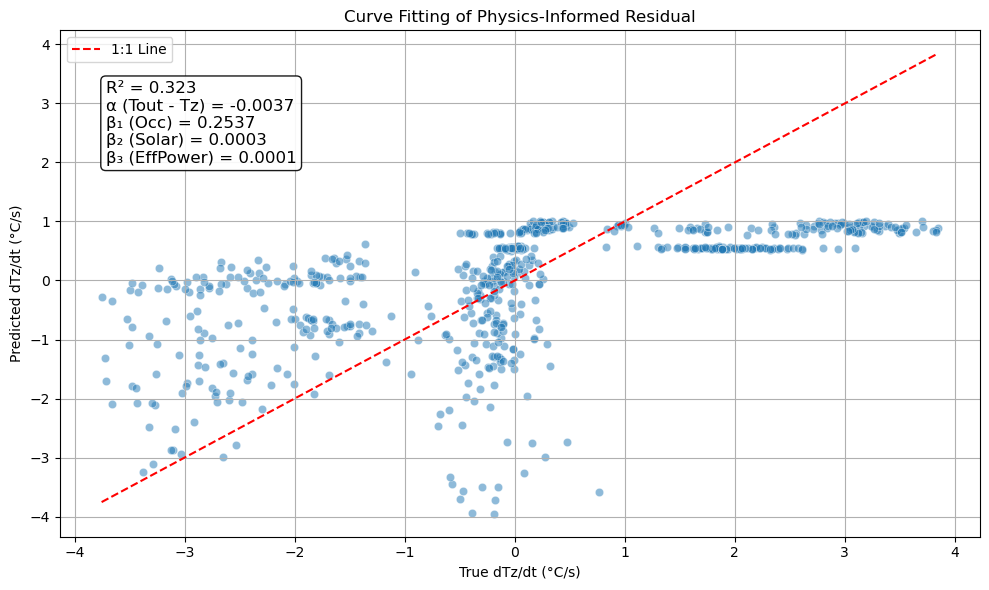

In [36]:
# Attention: I may need to consider different physical lawes for different control modes.

# Re-run required after kernel reset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# Load data
df = pd.read_csv("prepared_data_1hr.csv", index_col=0)

# Constants
dt = 3600.0  # seconds (1 hour)

# Extract relevant columns
Tz = df['tesBed.conVAVCor.TZon'].values
Tz_his = df['tesBed.conVAVCor.TZon_his1'].values
Tout = df['tesBed.TOut.y'].values
occ = df['tesBed.occSch.occupied'].values
solar = df['tesBed.weaBus.HGloHor'].values
power = df['Ptot'].values
uMod = df['tesBed.uModActual.y'].values

# Compute dTz/dt using finite difference
dTz_dt = (Tz - Tz_his) #/ dt

# Cooling active flag
cooling_active = ((uMod == 1) | (uMod == 2)).astype(float)
effective_power = power * cooling_active

# Construct regression inputs
X = np.column_stack([
    Tout - Tz,
    occ,
    solar,
    -effective_power
])
y = dTz_dt

# Fit linear regression model
reg = LinearRegression().fit(X, y)
alpha, beta1, beta2, beta3 = reg.coef_
intercept = reg.intercept_
r2 = reg.score(X, y)

# Use statsmodels for detailed summary
X_sm = sm.add_constant(X)
model = sm.OLS(y, X_sm).fit()

# Scatter plot with regression line
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6))
y_pred = reg.predict(X)
sns.scatterplot(x=y, y=y_pred, alpha=0.5, ax=ax)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='1:1 Line')
ax.set_xlabel("True dTz/dt (°C/s)")
ax.set_ylabel("Predicted dTz/dt (°C/s)")
ax.set_title("Curve Fitting of Physics-Informed Residual")
ax.grid(True)
ax.legend()

# Add regression summary annotation
textstr = '\n'.join((
    f'R² = {r2:.3f}',
    f'α (Tout - Tz) = {alpha:.4f}',
    f'β₁ (Occ) = {beta1:.4f}',
    f'β₂ (Solar) = {beta2:.4f}',
    f'β₃ (EffPower) = {beta3:.4f}',
))
props = dict(boxstyle='round', facecolor='white', alpha=0.9)
ax.text(0.05, 0.9, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

plt.tight_layout()


In [ ]:
# Feature mappings per zone
template_features = ['TZon_his1', 'uMod', 'T_out', 'occupied', 'solar', 'system_power']
zone_configs = {
    'core':  ([f'tesBed.conVAVCor.{template_features[0]}', 'tesBed.uModActual.y', 'tesBed.TOut.y',
              'tesBed.occSch.occupied', 'tesBed.weaBus.HGloHor', 'Ptot'], 'tesBed.conVAVCor.TZon'),
    # 'east':  ([f'tesBed.conVAVEas.{template_features[0]}', 'tesBed.uModActual.y', 'tesBed.TOut.y',
    #           'tesBed.occSch.occupied', 'tesBed.weaBus.HGloHor', 'Ptot'], 'tesBed.conVAVEas.TZon'),
    # 'north': ([f'tesBed.conVAVNor.{template_features[0]}', 'tesBed.uModActual.y', 'tesBed.TOut.y',
    #           'tesBed.occSch.occupied', 'tesBed.weaBus.HGloHor', 'Ptot'], 'tesBed.conVAVNor.TZon'),
    # 'south': ([f'tesBed.conVAVSou.{template_features[0]}', 'tesBed.uModActual.y', 'tesBed.TOut.y',
    #           'tesBed.occSch.occupied', 'tesBed.weaBus.HGloHor', 'Ptot'], 'tesBed.conVAVSou.TZon'),
    # 'west':  ([f'tesBed.conVAVWes.{template_features[0]}', 'tesBed.uModActual.y', 'tesBed.TOut.y',
    #           'tesBed.occSch.occupied', 'tesBed.weaBus.HGloHor', 'Ptot'], 'tesBed.conVAVWes.TZon')
}

### Post-analysis of model performance


--- Evaluating Open-Loop for CORE Zone ---

📊 Open-loop results for CORE:
RMSE = 4.497 °C, CVRMSE = 17.65 %, R² = -9.787


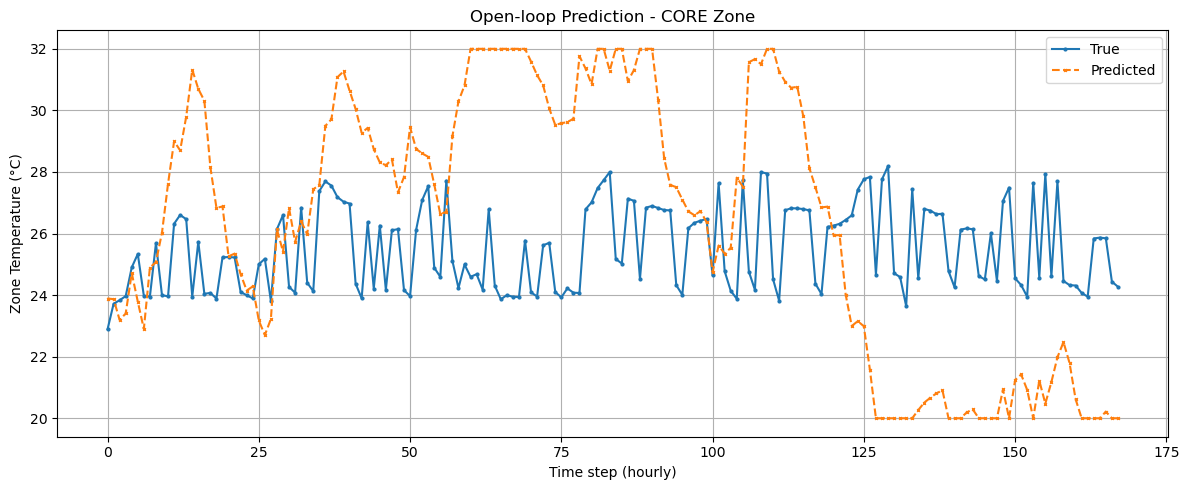

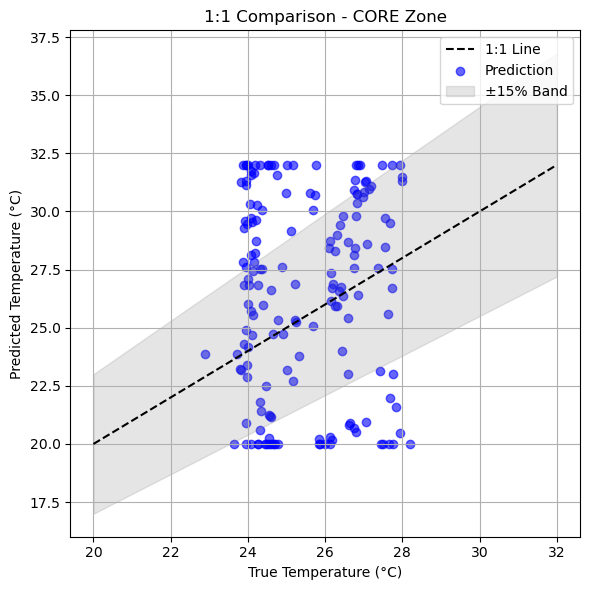

In [22]:
# === Open-loop Testing ===
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def open_loop_pinn(model_path, data, features, target, updated_var_name, start_day, num_days, timestep=3600, zone_name="zone"):
    model = tf.keras.models.load_model(model_path, compile=False)
    X = data[features].values.astype(np.float32)
    Y = data[target].values.astype(np.float32)
    updated_idx = features.index(updated_var_name)

    steps_per_day = int(24 * 3600 / timestep)
    total_steps = int(num_days * steps_per_day)
    start_step = int(start_day * steps_per_day)

    if start_step + total_steps > len(X):
        raise ValueError("Not enough data points for simulation.")

    y_pred = []
    y_true = []

    predicted_val = X[start_step, updated_idx]

    for i in range(total_steps):
        input_now = X[start_step + i:start_step + i + 1].copy()
        input_now[0, updated_idx] = predicted_val
        predicted_val = model(input_now).numpy()[0][0]
        predicted_val = np.clip(predicted_val, 20, 32)

        y_pred.append(predicted_val)
        y_true.append(Y[start_step + i])

    y_pred = np.array(y_pred)
    y_true = np.array(y_true)

    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    r2 = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)
    cvrmse = (rmse / np.mean(y_true)) * 100

    print(f"\n📊 Open-loop results for {zone_name.upper()}:")
    print(f"RMSE = {rmse:.3f} °C, CVRMSE = {cvrmse:.2f} %, R² = {r2:.3f}")

    plt.figure(figsize=(12, 5))
    plt.plot(y_true, label="True", marker='o', markersize=2)
    plt.plot(y_pred, label="Predicted", linestyle='--', marker='x', markersize=2)
    plt.xlabel("Time step (hourly)")
    plt.ylabel("Zone Temperature (°C)")
    plt.title(f"Open-loop Prediction - {zone_name.upper()} Zone")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"./results_pinn/open_loop_{zone_name}_zone.png")
    plt.show()

    return y_true, y_pred

def plot_scatter_true_vs_pred(y_true, y_pred, zone_name="zone"):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.6, color='blue', label='Prediction')
    min_val, max_val = min(min(y_true), min(y_pred)), max(max(y_true), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='1:1 Line')
    plt.fill_between([min_val, max_val],
                     [0.85 * min_val, 0.85 * max_val],
                     [1.15 * min_val, 1.15 * max_val],
                     color='gray', alpha=0.2, label='±15% Band')
    plt.xlabel("True Temperature (°C)")
    plt.ylabel("Predicted Temperature (°C)")
    plt.title(f"1:1 Comparison - {zone_name.upper()} Zone")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"./results_pinn/scatter_{zone_name}_zone.png")
    plt.show()

# Run for all 5 zones
zone_features = {
    'core':  ('tesBed.conVAVCor.TZon_his1', 'tesBed.conVAVCor.TZon'),
    # 'east':  ('tesBed.conVAVEas.TZon_his1', 'tesBed.conVAVEas.TZon'),
    # 'north': ('tesBed.conVAVNor.TZon_his1', 'tesBed.conVAVNor.TZon'),
    # 'south': ('tesBed.conVAVSou.TZon_his1', 'tesBed.conVAVSou.TZon'),
    # 'west':  ('tesBed.conVAVWes.TZon_his1', 'tesBed.conVAVWes.TZon')
}

base_features = ['tesBed.uModActual.y','tesBed.TOut.y','tesBed.occSch.occupied','tesBed.weaBus.HGloHor','Ptot']

for zone, (hist_var, target_var) in zone_features.items():
    features = [hist_var] + base_features
    print(f"\n--- Evaluating Open-Loop for {zone.upper()} Zone ---")
    true_vals, pred_vals = open_loop_pinn(
        model_path=f'./results_pinn/pinn_model_{zone}.h5',
        data=df,
        features=features,
        target=target_var,
        updated_var_name=hist_var,
        start_day=0,
        num_days=7,
        timestep=3600,
        zone_name=zone
    )
    plot_scatter_true_vs_pred(true_vals, pred_vals, zone)
